# Simulated IRFs from an RBC Model

This code creates a very simple RBC model with random technology shocks. We simulate data from this model, create the true impulse response functions, and then estimate them using VAR, LP, and SLP methods.

The model has period utility $u_t=\log(C_t)$, production function $Y_t = e^{z_t}K^{\alpha}_t$, technology evolution $z_t = \rho z_{t-1}+\varepsilon_t$ with $\varepsilon_t \sim \mathcal N(0,\sigma^2)$, and resource constraint $C_t+K_{t+1}=Y_t$. The advantage of this simple model (with full depreciation, inelastic labour, and log utility) is that the policy function of the household has a closed-form solution.

The econometrician observes $K_t, Y_t, Z_t$ with noise, where $Z_t=e^{z_t}$. It is assumed that the model and lag structure are unknown to the econometrician.

In [1]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

# set seed for reproducibility
np.random.seed(405)

In [2]:
# Set parameters for RBC model
beta = 0.99      # Quarterly discount factor - must be in (0,1)
alpha = 0.33     # Capital share in production function - must be in (0,1)
rho = 0.9        # Persistence of technology shock - must be in (0,1)
sigma_z = 0.075  # Standard deviation of technology shock - must be positive
sigma_obs = 0.05 # Standard deviation of noise in observed data - must be positive (if too much bigger than sigma_z estimation will be hard)
q = 8            # Number of quarters for IRF - must be greater than 7 or SLP is poorly conditioned with default smoothing parameter
T = 80           # Number of quarters for simulated data - must be sufficient for estimation

In [3]:
# Helper function to plot IRFs
def plot_irf_combined(true_irf, var, LP, SLP):
    varnames = ['Capital', 'Output', 'Technology']
    methods = {
        'True':  (true_irf, 'black',   'o'),
        'SLP':   (SLP,      '#DC143C', 's'),   # crimson
        'LP':    (LP,       '#1565C0', '^'),   # deep blue
        'VAR':   (var,      '#E65C00', 'D'),   # vivid orange
    }
    horizons = range(true_irf.shape[0])
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, ax in enumerate(axes):
        for label, (data, color, marker) in methods.items():
            ax.plot(horizons, data.iloc[:, i], color=color, marker=marker,
                    markersize=5, linewidth=1.4, label=label)
        ax.axhline(0, color='black', linestyle='dashed', linewidth=0.8)
        ax.set_title(f'Technology → {varnames[i]}')
        ax.set_xlabel('Quarters')
        ax.set_ylabel('Response')
        ax.legend(fontsize=8)
    fig.suptitle('Impulse Response Functions to Technology Shock', fontsize=13)
    plt.tight_layout()
    plt.show()

### Simulating data

We start by generating some simulated data from the RBC model with the parameters defined above.

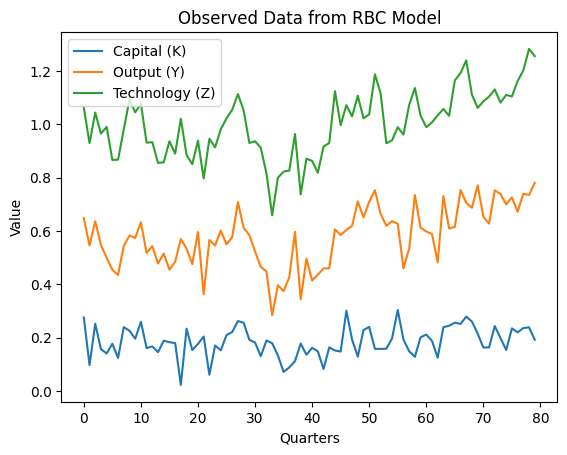

In [4]:
# Create simulated time series data for simple RBC model
def gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T):

    # check for valid model parameters
    assert beta > 0 and beta < 1, "beta must be in (0,1)"
    assert alpha > 0 and alpha < 1, "alpha must be in (0,1)"
    assert rho > 0 and rho < 1, "alpha must be in (0,1)"
    assert sigma_z > 0, "sigma_z must be positive"
    assert sigma_obs > 0, "sigma_obs must be positive"
    
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(T)
    C = np.zeros(T)
    z = np.zeros(T)
    Y = np.zeros(T)

    K[0] = ss_K
    C[0] = ss_C
    Y[0] = K[0]**alpha

    for t in range(1, T):
        z[t] = rho * z[t-1] + sigma_z * np.random.normal()
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha # Closed-form solution for capital accumulation
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha # Closed-form solution for consumption
        
    # add noise
    Z = np.exp(z) + np.random.normal(0, sigma_obs, size=T)
    Y = Z*K**alpha + np.random.normal(0, sigma_obs, size=T)
    K = K + np.random.normal(0, sigma_obs, size=T)

    return pd.DataFrame({"Capital": K, "Output": Y, "Technology": Z})

observed_data = gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T)

# Plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from RBC Model")
plt.xlabel("Quarters")
plt.ylabel("Value")
plt.legend(["Capital (K)", "Output (Y)", "Technology (Z)"])
plt.show()

### Generating true IRFs

A common usage of the RBC model is to analyse how technology shocks propagate through capital $K$ and output $Y$. Below, we obtain the true impulse response functions for a unit technology shock in the RBC model with the chosen parameters. This is what the econometrician is trying to estimate from the observed data.

In [5]:
def gen_irf(beta, alpha, rho, q):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(q+1)
    C = np.zeros(q+1)
    z = np.zeros(q+1)
    Y = np.zeros(q+1)

    z[0] = np.log(2) # Unit shock to Z
    K[0] = ss_K
    C[0] = ss_C

    for t in range(1, q+1):
        z[t] = rho * z[t-1]
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha

    Z = np.exp(z) - 1
    Y = np.exp(z)*K**alpha - ss_K**alpha
    K = K - ss_K

    return pd.DataFrame({"Capital": K, "Output": Y, "Technology": Z})

true_irf = gen_irf(beta, alpha, rho, q)

### Estimating the impulse responses

We now turn our attention to estimation of impulse responses on the simulated RBC data to see how well the SLP procedure recovers underlying impulse responses for a known data generating process, as well to compare how the method fares with vanilla local projections and VAR models. The VAR model and LP derivatives use the same lag structure.

In [6]:
# VAR estimation of IRFs
var_mod = VAR(observed_data)
opt_lags = var_mod.select_order(maxlags = 10).aic
var_fit = var_mod.fit(opt_lags)
var_irfs = var_fit.irf(periods = q).irfs
var_beta = pd.DataFrame(var_irfs[:,:,2])

# LP/SLP estimation of IRFs
LP_mod = SmoothLocalProjections(observed_data, shock = "Technology", endog = None, shock_exo = True, p = opt_lags, H = q)
LP_fit = LP_mod.LP()
SLP_fit = LP_mod.SLP()

LP_beta = pd.DataFrame(LP_fit.beta)
SLP_beta = pd.DataFrame(SLP_fit.beta)

### Results

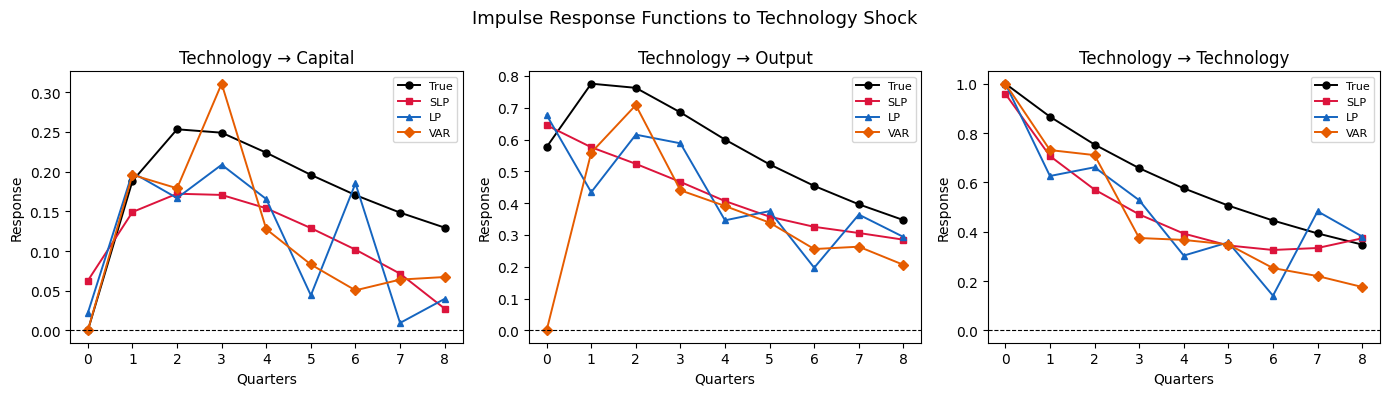

In [7]:
plot_irf_combined(true_irf, var_beta, LP_beta, SLP_beta)

### Discussion
The accuracy of these estimation procedures can be compared by calculating the mean squared error (MSE) of each.

In [8]:
print(f"MSE of VAR IRFs: {np.mean((true_irf.values - var_beta.values)**2)}")
print(f"MSE of LP IRFs: {np.mean((true_irf.values - LP_beta.values)**2)}")
print(f"MSE of SLP IRFs: {np.mean((true_irf.values - SLP_beta.values)**2)}")

MSE of VAR IRFs: 0.03401501558242622
MSE of LP IRFs: 0.024406721573432863
MSE of SLP IRFs: 0.017213561241737386


As expected based on the plots, the SLP estimated IRF is closest to the true IRF. In order to ensure that this result is not due to the specific pattern of shocks drawn the procedure should be average over multiple iterations. For simplicity and computational speed it is assumed from now on that the lag structure is known.

In [9]:
# Calculating the average mean squared error (MSE) over 500 simulations
num = 500
var_MSE = np.zeros(num)
LP_MSE = np.zeros(num)
SLP_MSE = np.zeros(num)

for i in range(num):
    observed_data = gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T)
    true_irf = gen_irf(beta, alpha, rho, q)
    
    var_mod = VAR(observed_data)
    var_fit = var_mod.fit(1)
    var_irfs = var_fit.irf(periods=q).irfs
    var_beta = pd.DataFrame(var_irfs[:,:,2])

    LP_mod = SmoothLocalProjections(observed_data, "Technology", None, True, 1, q)
    LP_beta = pd.DataFrame(LP_mod.LP().beta)
    SLP_beta = pd.DataFrame(LP_mod.SLP().beta)

    var_MSE[i] = np.mean((true_irf.values - var_beta.values)**2)
    LP_MSE[i] = np.mean((true_irf.values - LP_beta.values)**2)
    SLP_MSE[i] = np.mean((true_irf.values - SLP_beta.values)**2)

avg_var_MSE = np.mean(var_MSE)
avg_LP_MSE = np.mean(LP_MSE)
avg_SLP_MSE = np.mean(SLP_MSE)

print(f"Average MSE of VAR IRFs over {num} simulations: {avg_var_MSE:.5f}")
print(f"Average MSE of LP IRFs over {num} simulations: {avg_LP_MSE:.5f}")
print(f"Average MSE of SLP IRFs over {num} simulations: {avg_SLP_MSE:.5f}")

Average MSE of VAR IRFs over 500 simulations: 0.06660
Average MSE of LP IRFs over 500 simulations: 0.04172
Average MSE of SLP IRFs over 500 simulations: 0.03699


From the above calculations it is clear that SLPs have an advantage over LPs and VARs when the underlying DGP follows this nonlinear process. Examining the plots suggests that a weakness of VAR is failing to capture the simultaneous effect on output resulting from a technology shock, while the LP estimate is too jagged compared to the relatively smooth underlying process. In the plotted examples none of the estimation strategies successfully capture the magnitude of the output or capital increases.

Also of interest is how the relative accuracy changes with observation noise.

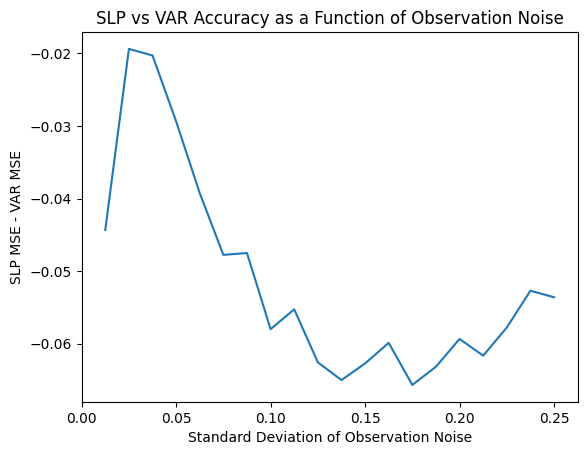

In [10]:
# Evaluating how the difference in MSE changes with observation noise
num = 100
rng = 20
MSE_diff = np.zeros((rng,2))

for i in range(rng):
    sigma_obs = (i+1)/80 # sigma_obs from 0.0125 to 0.25 in 0.0125 increments
    var_MSE = np.zeros(num)
    SLP_MSE = np.zeros(num)

    for j in range(num):
        observed_data = gen_macro_ts(beta, alpha, rho, sigma_z, sigma_obs, T)
        true_irf = gen_irf(beta, alpha, rho, q)
    
        var_mod = VAR(observed_data)
        var_fit = var_mod.fit(1)
        var_irfs = var_fit.irf(periods=q).irfs
        var_beta = pd.DataFrame(var_irfs[:,:,2])

        LP_mod = SmoothLocalProjections(observed_data, "Technology", None, True, 1, q)
        SLP_beta = pd.DataFrame(LP_mod.SLP().beta)

        var_MSE[j] = np.mean((true_irf.values - var_beta.values)**2)
        SLP_MSE[j] = np.mean((true_irf.values - SLP_beta.values)**2)

    MSE_diff[i,0] = np.mean(SLP_MSE) - np.mean(var_MSE)
    MSE_diff[i,1] = sigma_obs

MSE_diff = pd.DataFrame(MSE_diff)

plt.plot(MSE_diff[1], MSE_diff[0])
plt.xlabel("Standard Deviation of Observation Noise")
plt.ylabel("SLP MSE - VAR MSE")
plt.title("SLP vs VAR Accuracy as a Function of Observation Noise")
plt.xlim((0,0.2625))
plt.show()

SLP estimates are more accurate than VAR estimates for all examined levels of noise, and the advantage seems to increase as observations become noisier (although the right end does show some convergence).